In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [3]:
import ydf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

print("YDF version:", ydf.__version__)

YDF version: 0.16.1


In [5]:
train_file_path = "/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv"

ydf_dataset = pd.read_csv(train_file_path)

print("Full train dataset shape:", ydf_dataset.shape)

Full train dataset shape: (1460, 81)


In [6]:
ydf_dataset = ydf_dataset.drop("Id", axis=1)

ydf_dataset.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


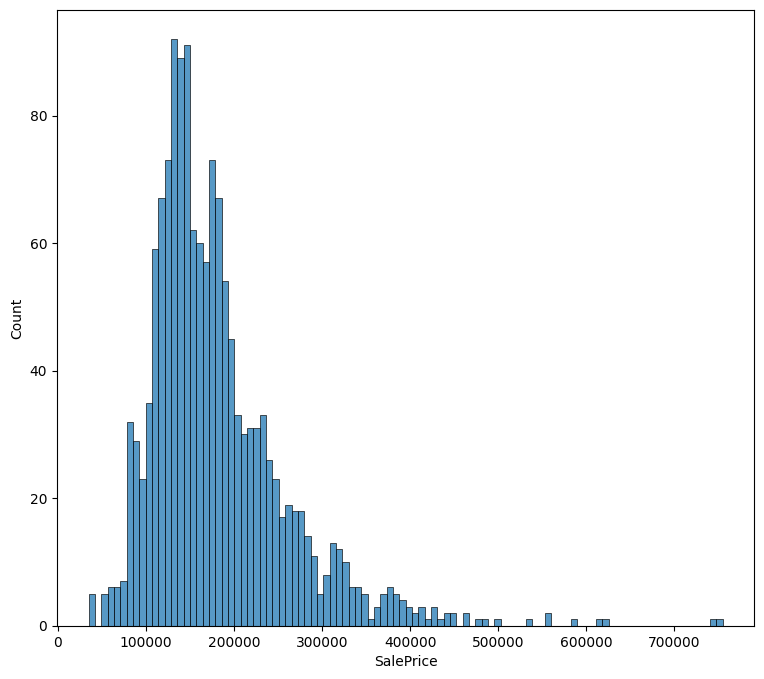

In [7]:
print(ydf_dataset["SalePrice"].describe())

plt.figure(figsize=(9, 8))

sns.histplot(
    ydf_dataset["SalePrice"],
    bins=100
)

plt.show()

In [8]:
ydf_df_num = ydf_dataset.select_dtypes(
    include=["float64", "int64"]
)

ydf_df_num.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000


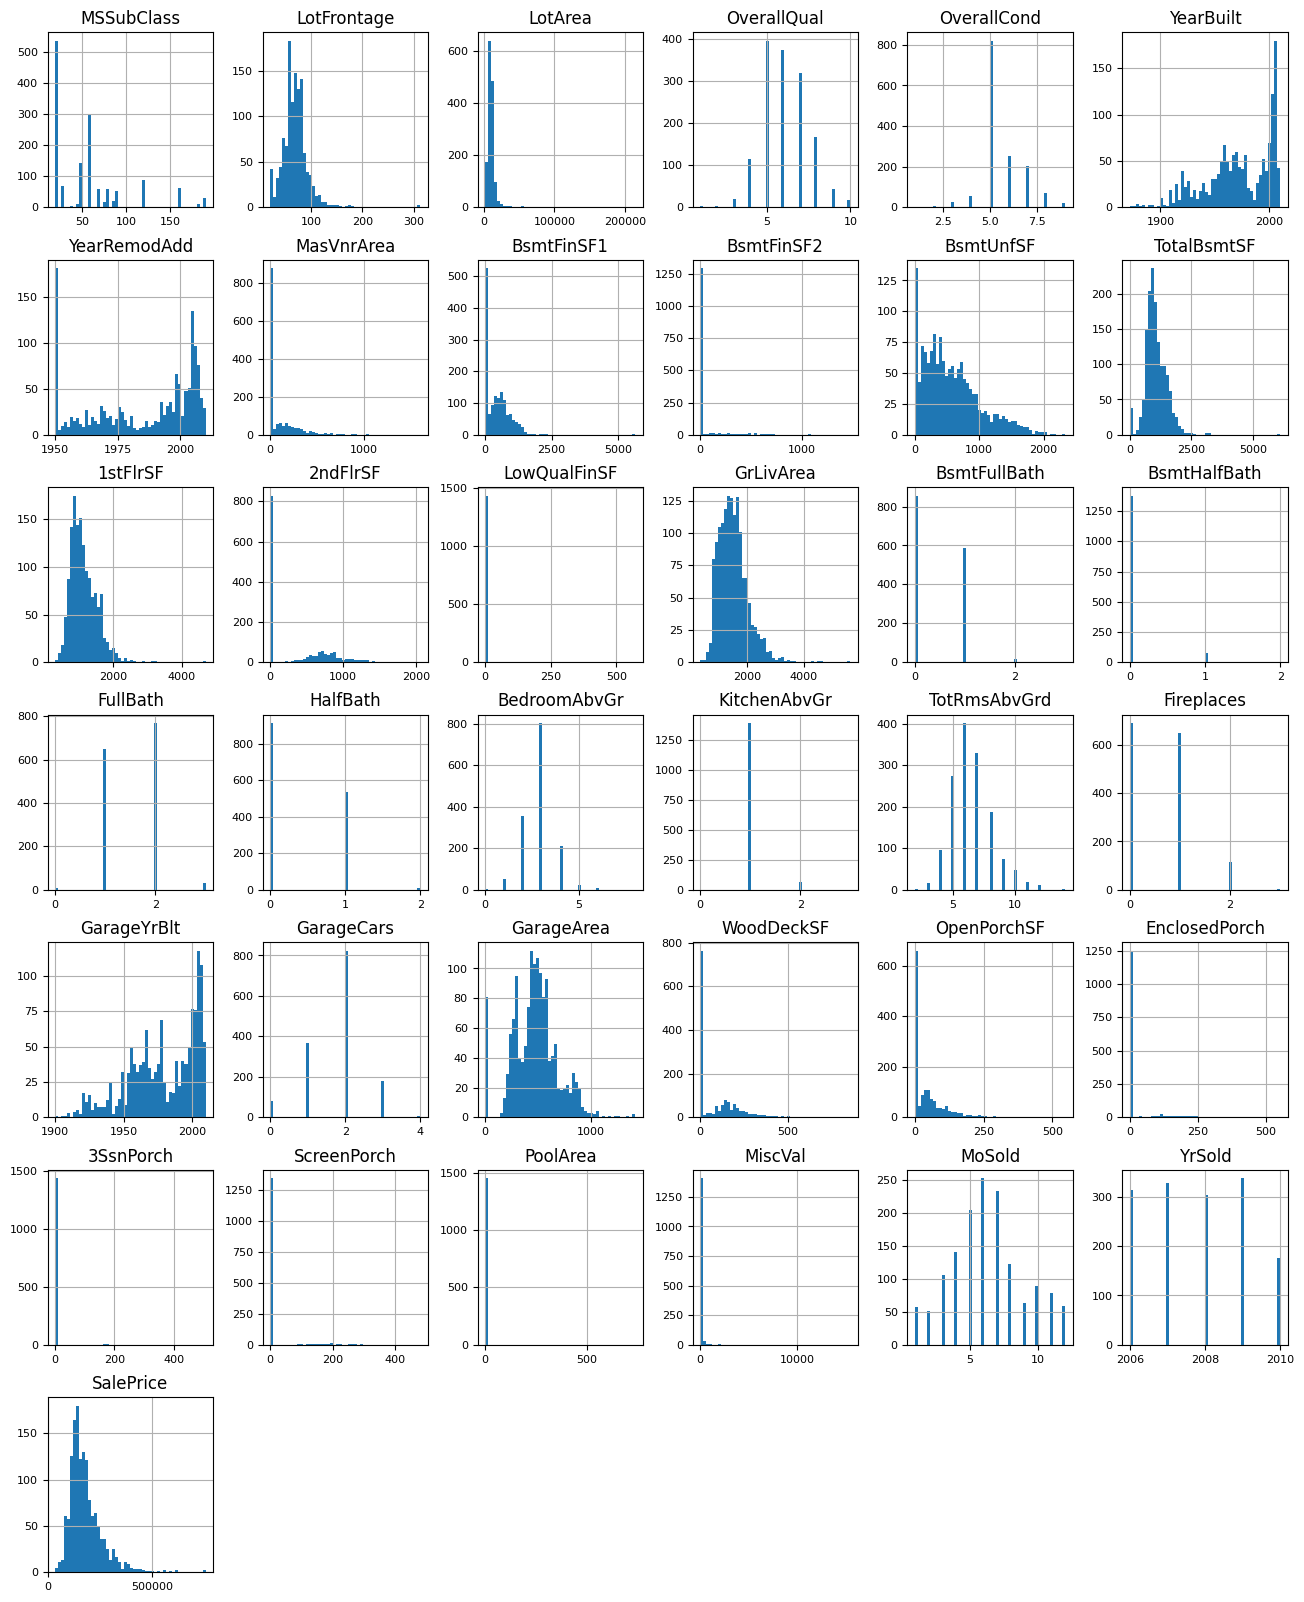

In [9]:
ydf_df_num.hist(
    figsize=(16, 20),
    bins=50,
    xlabelsize=8,
    ylabelsize=8
)

plt.show()

In [10]:
def split_dataset(dataset, test_ratio=0.30):
    test_indices = np.random.rand(len(dataset)) < test_ratio

    return (
        dataset[~test_indices],
        dataset[test_indices]
    )


ydf_train_pd, ydf_valid_pd = split_dataset(
    ydf_dataset
)

print(
    "{} examples in training, {} examples in testing.".format(
        len(ydf_train_pd),
        len(ydf_valid_pd)
    )
)

1015 examples in training, 445 examples in testing.


In [11]:
ydf_rf = ydf.RandomForestLearner(
    label="SalePrice",
    task=ydf.Task.REGRESSION,
    num_trees=300
).train(
    ydf_train_pd
)

Feature Utilities is a CATEGORICAL feature whose dictionary has a single element. The feature will not be useful during model training.
Feature Condition2 is a CATEGORICAL feature whose dictionary has a single element. The feature will not be useful during model training.
Feature PoolQC is a CATEGORICAL feature with an empty dictionary. The feature will not be useful during model training.
Feature MiscFeature is a CATEGORICAL feature whose dictionary has a single element. The feature will not be useful during model training.
Train model on 1015 examples
Model trained in 0:00:01.471320


In [12]:
ydf_rf.describe()

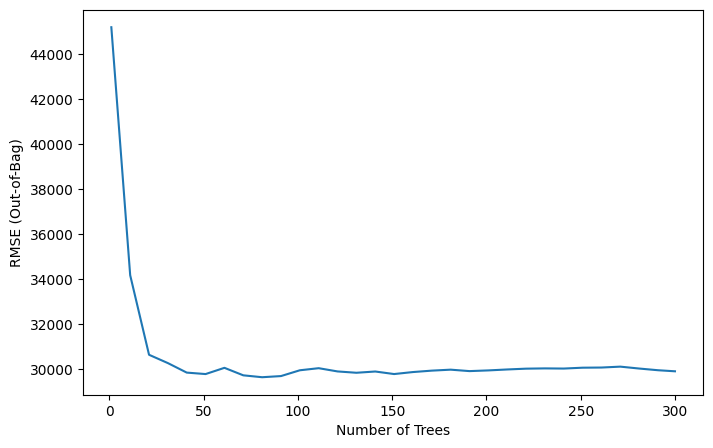

In [13]:
ydf_logs = ydf_rf.training_logs()

plt.figure(figsize=(8, 5))

plt.plot(
    [log.iteration for log in ydf_logs],
    [log.evaluation.rmse for log in ydf_logs]
)

plt.xlabel("Number of Trees")
plt.ylabel("RMSE (Out-of-Bag)")

plt.show()

In [14]:
ydf_rf.self_evaluation()

Evaluation()

In [15]:
ydf_evaluation = ydf_rf.evaluate(
    ydf_valid_pd
)

print(ydf_evaluation)

RMSE: 25972.4
num examples: 445
num examples (weighted): 445



In [16]:
print(
    "Validation RMSE:",
    ydf_evaluation.rmse
)

Validation RMSE: 25972.39886393804


In [17]:
print("Available variable importances:")

for importance in ydf_rf.variable_importances().keys():
    print("\t", importance)

Available variable importances:
	 SUM_SCORE
	 NUM_NODES
	 INV_MEAN_MIN_DEPTH
	 NUM_AS_ROOT


In [18]:
ydf_rf.variable_importances()["NUM_AS_ROOT"]

[(106.0, 'OverallQual'),
 (42.0, 'ExterQual'),
 (41.0, 'GarageCars'),
 (39.0, 'Neighborhood'),
 (20.0, 'GrLivArea'),
 (14.0, 'GarageArea'),
 (9.0, 'KitchenQual'),
 (8.0, 'BsmtQual'),
 (8.0, 'TotalBsmtSF'),
 (5.0, 'YearBuilt'),
 (4.0, 'GarageYrBlt'),
 (3.0, '1stFlrSF'),
 (1.0, '2ndFlrSF')]

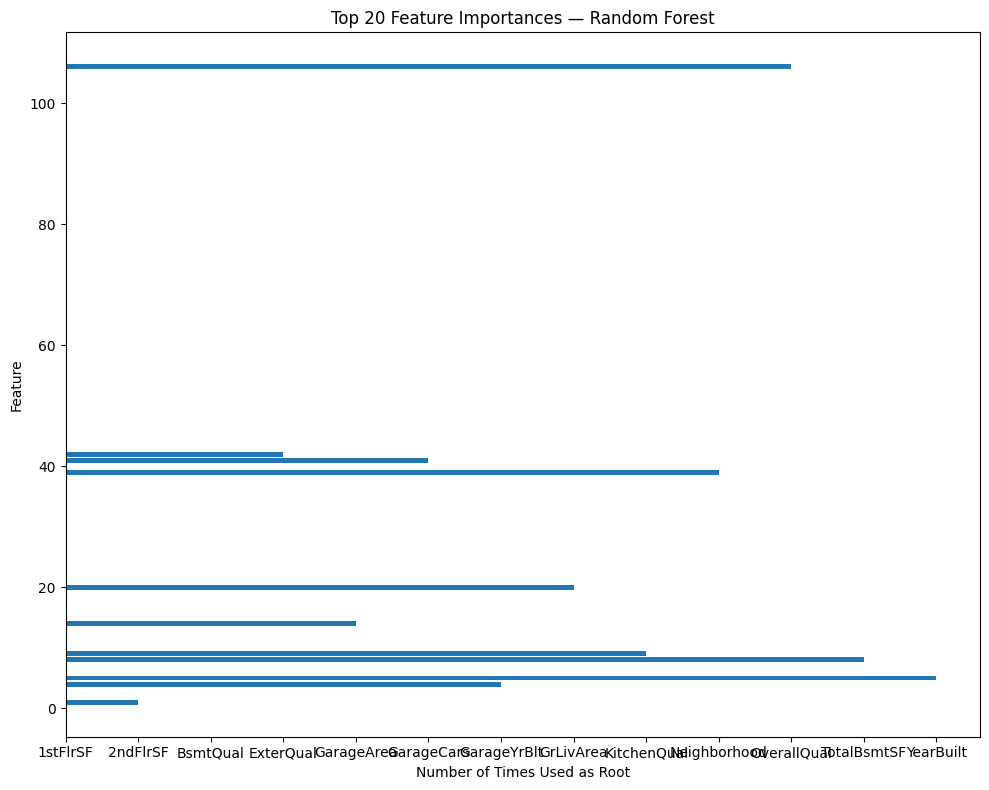

In [26]:
variable_importance_metric = "NUM_AS_ROOT"

variable_importances = ydf_rf.variable_importances()[
    variable_importance_metric
]

feature_names = [
    vi[0]
    for vi in variable_importances
]

feature_importances = [
    vi[1]
    for vi in variable_importances
]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

importance_df = (
    importance_df
    .sort_values("Importance", ascending=False)
    .head(20)
    .sort_values("Importance", ascending=True)
)

plt.figure(figsize=(10, 8))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Number of Times Used as Root")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances — Random Forest")

plt.tight_layout()
plt.show()

In [21]:
test_file_path = "/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv"

ydf_test_data = pd.read_csv(
    test_file_path
)

ydf_ids = ydf_test_data.pop("Id")

In [22]:
ydf_preds = ydf_rf.predict(
    ydf_test_data
)

print(ydf_preds[:10])

print(
    "Number of predictions:",
    len(ydf_preds)
)

[126644.56 153842.66 183413.58 187340.14 197097.69 182518.94 169825.58
 176392.88 176278.   126956.39]
Number of predictions: 1459


In [23]:
ydf_submission = pd.DataFrame({
    "Id": ydf_ids,
    "SalePrice": ydf_preds
})

ydf_submission.head()

,Id,SalePrice
0,1461,126644.562500
1,1462,153842.656250
2,1463,183413.578125
3,1464,187340.140625
4,1465,197097.687500


In [24]:
ydf_submission.to_csv(
    "submission-1x",
    index=False
)

print("Submission saved!")

Submission saved!
